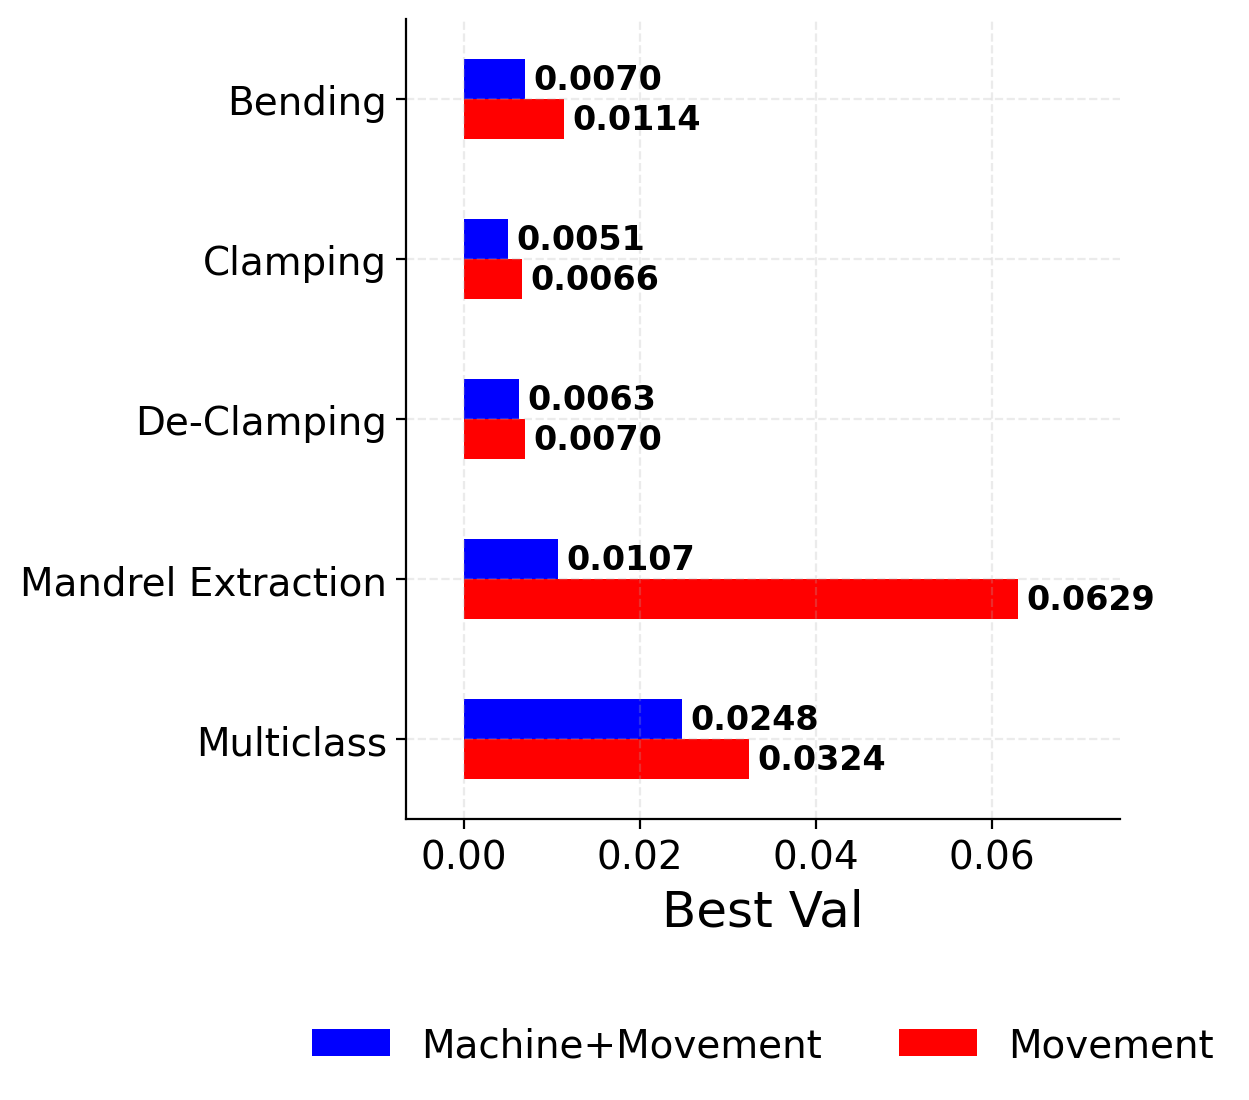

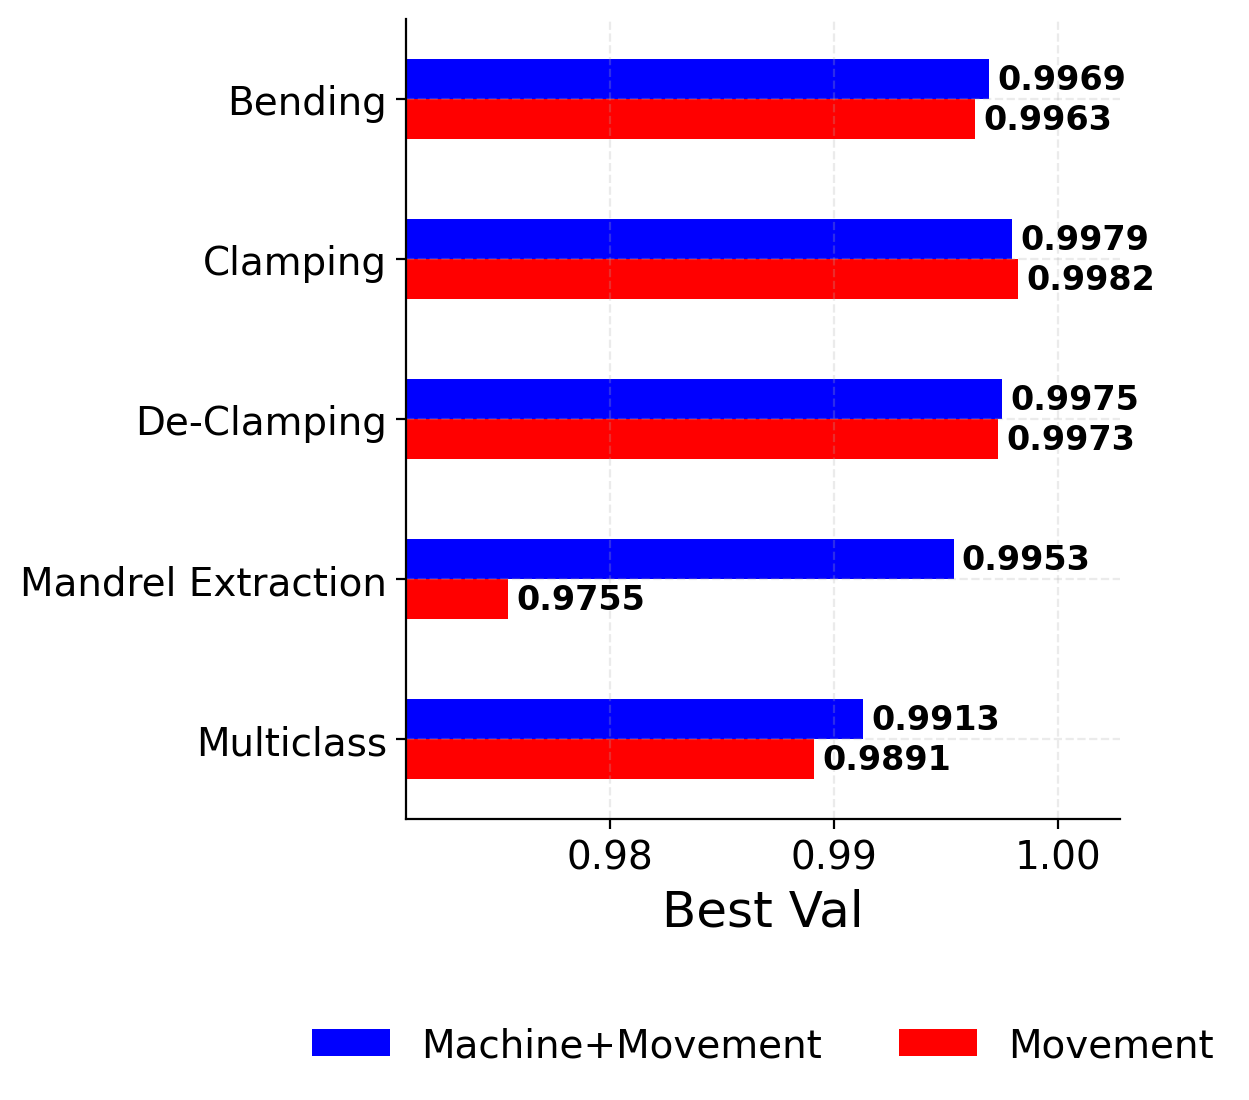

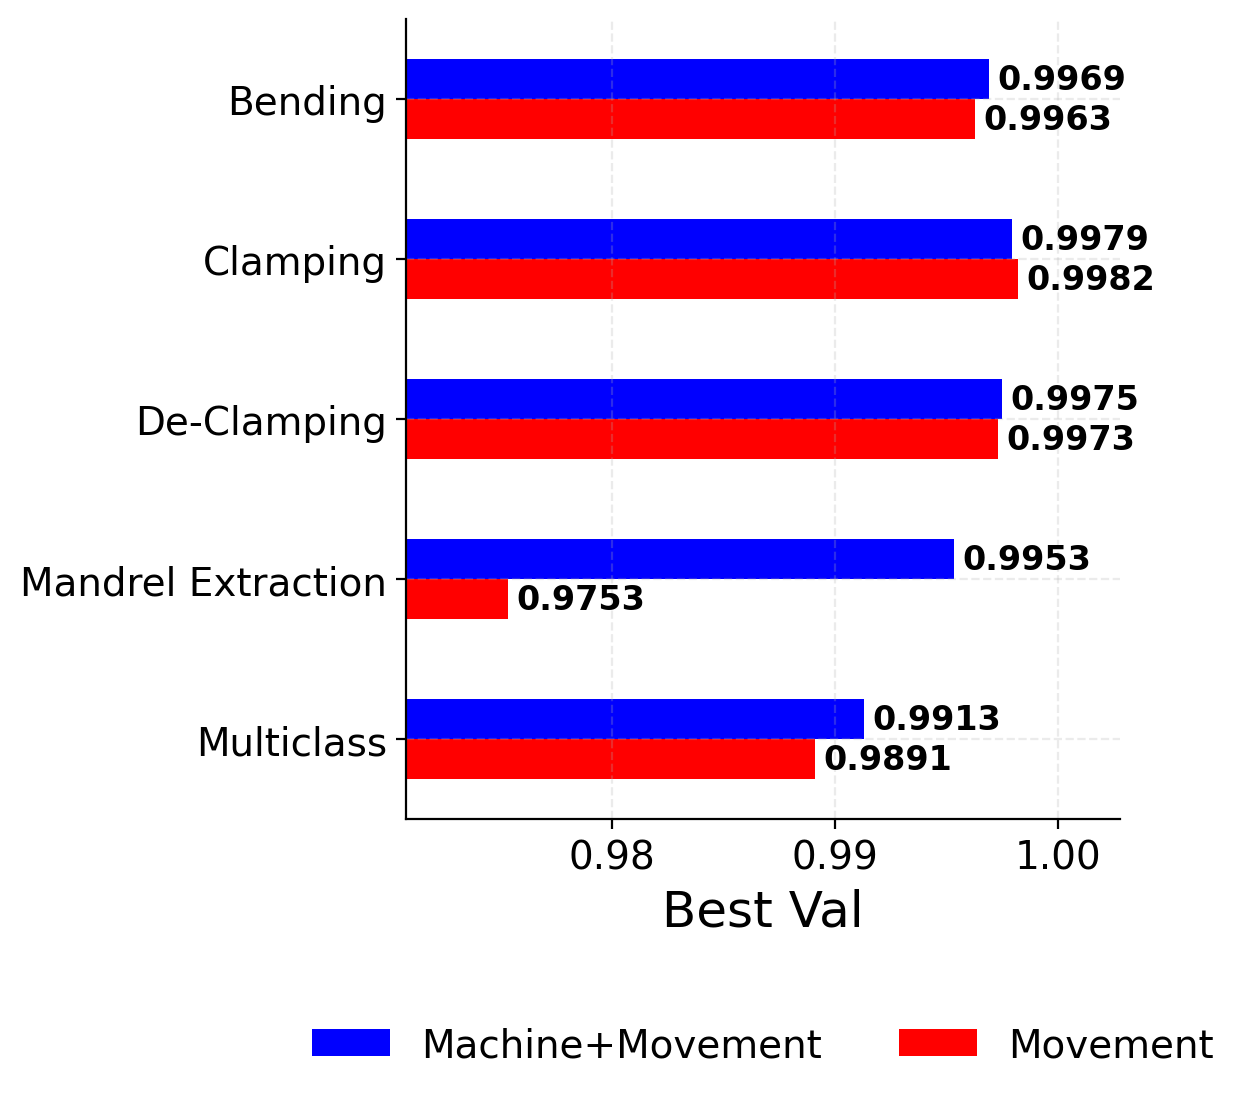

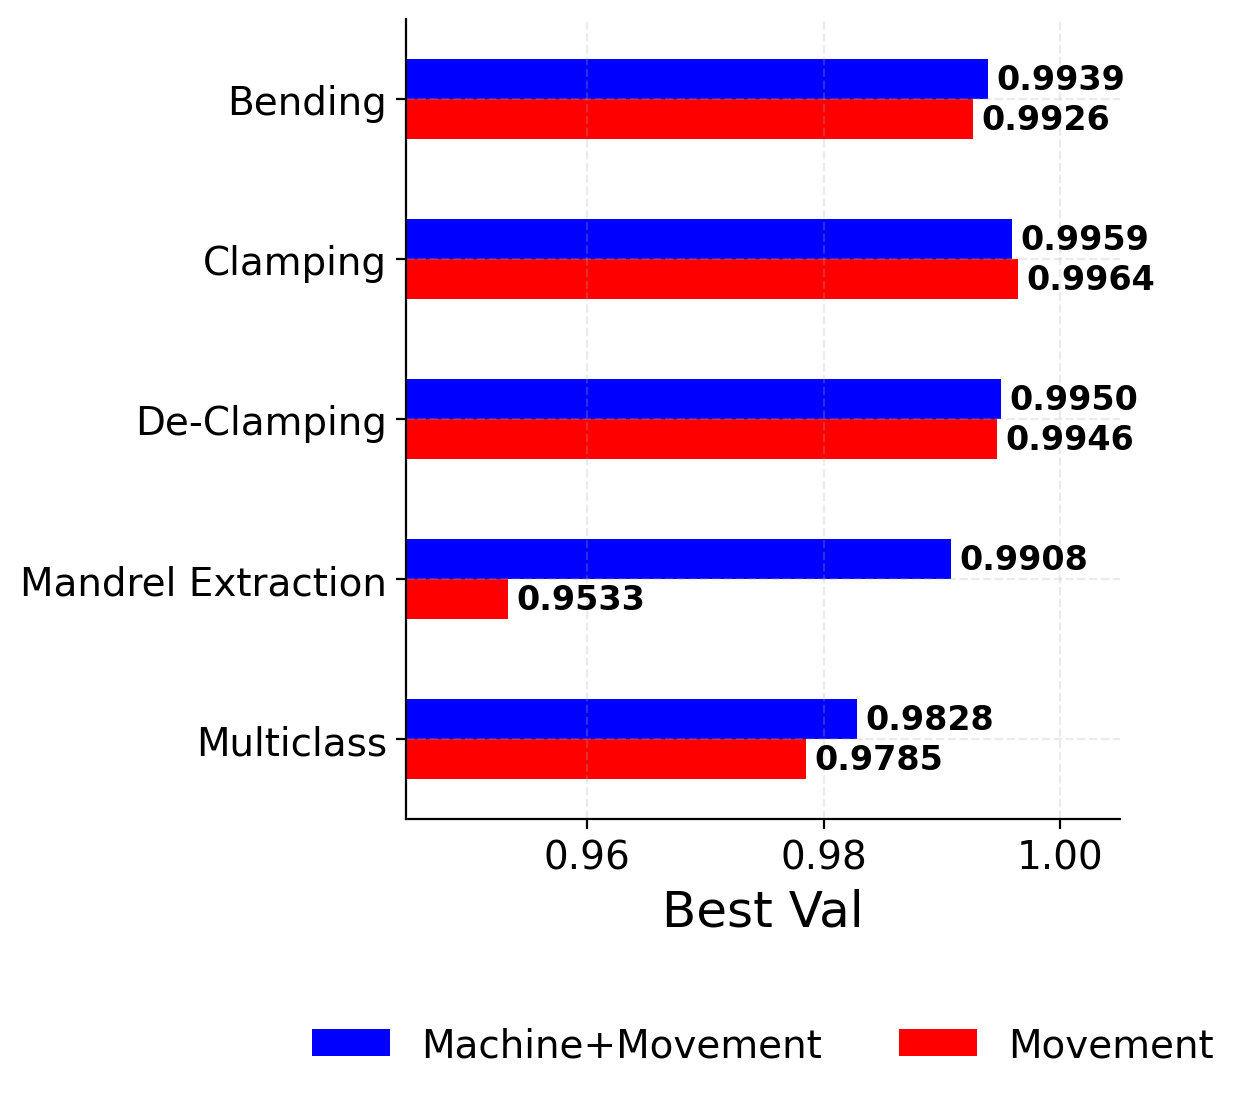

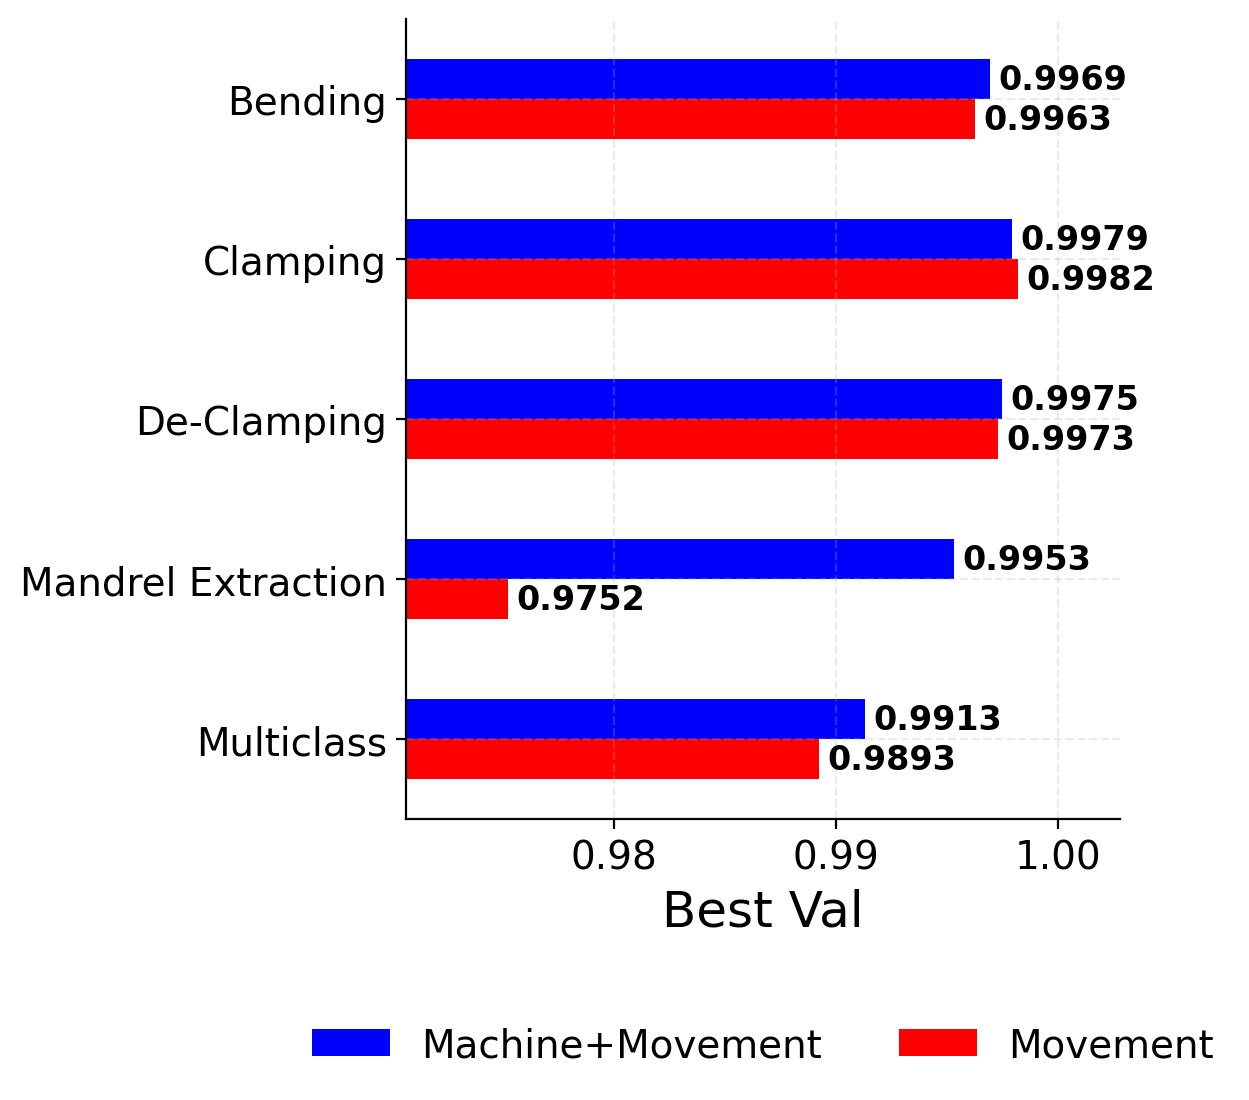

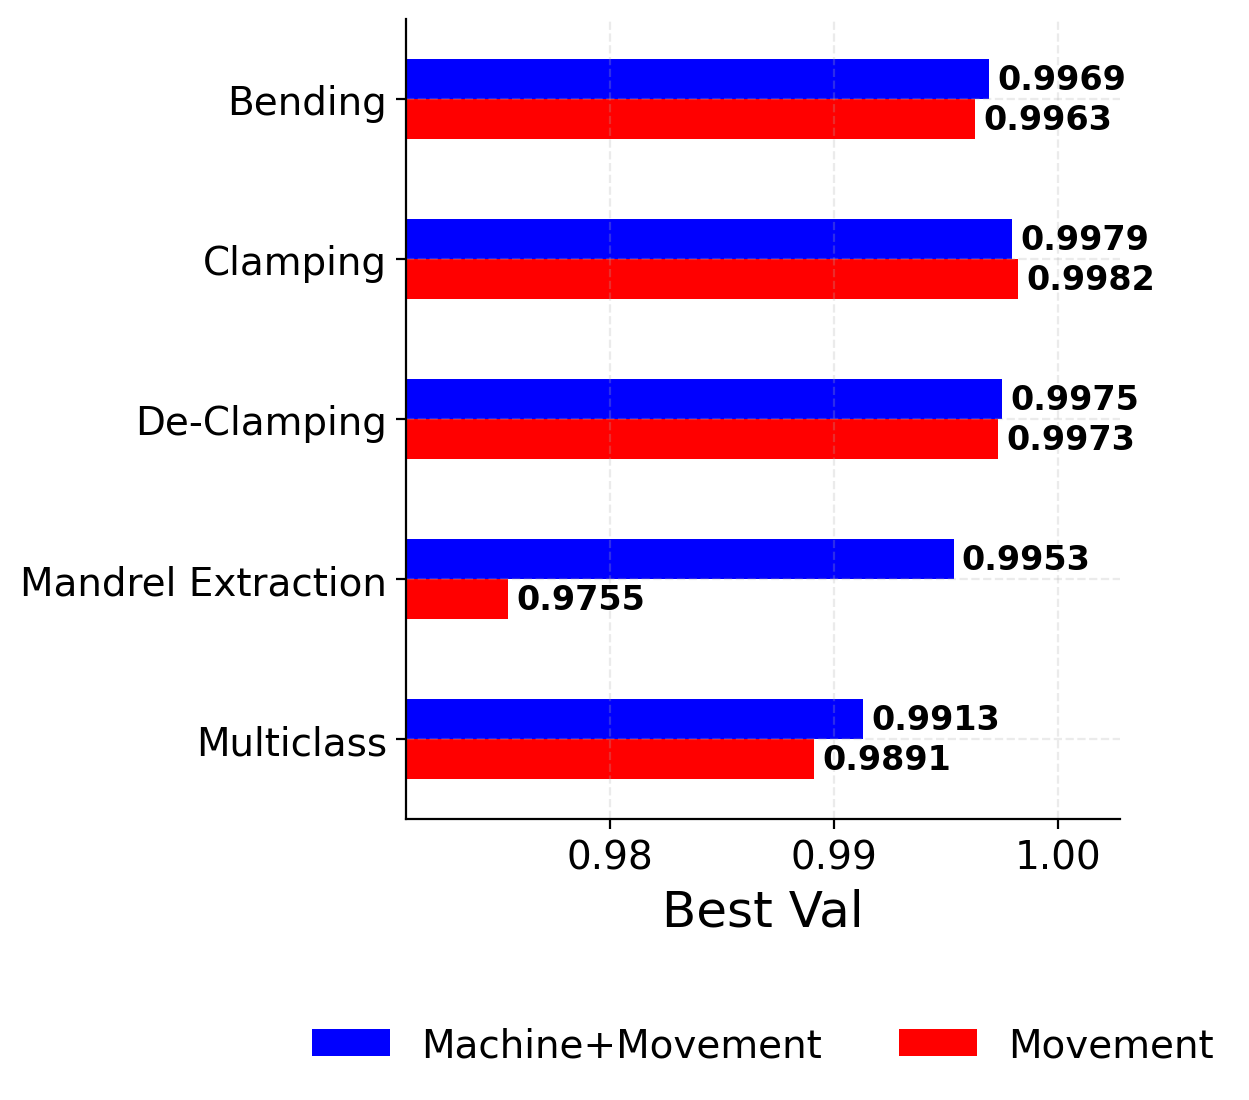

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# Paths
# =====================================
root_dir = "results/activity_recognition"
pattern = os.path.join(root_dir, "metrics_best_last_summary_*.csv")

output_dir = os.path.join(root_dir, "paper_comparison_plots")
os.makedirs(output_dir, exist_ok=True)

value_column = "Best Val"

process_part_order = [
    "All",
    "Bending",
    "Clamping",
    "De-Clamping",
    "Mandrel Extraction",
]

metric_order = [
    "Loss",
    "Accuracy",
    "F1",
    "IoU",
    "Precision",
    "Recall",
]

# =====================================
# Plot style
# =====================================
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# =====================================
# Helpers
# =====================================
def safe_name(text):
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")

def extract_process_part(file_path):
    name = os.path.basename(file_path)
    name = name.replace("metrics_best_last_summary_", "")
    name = name.replace(".csv", "")
    name = name.replace("_", " ")

    if name == "All":
        name = "Multiclass"

    return name

# =====================================
# Load CSV files
# =====================================
dfs = []

for file_path in glob.glob(pattern):

    df = pd.read_csv(file_path)

    if df.empty:
        continue

    process_part = extract_process_part(file_path)
    df["Process Part"] = process_part
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data[value_column] = pd.to_numeric(data[value_column], errors="coerce")

data = data.dropna(subset=["Process Part","Experiment","Metric",value_column])

# Order process parts
available_parts = data["Process Part"].unique().tolist()
final_part_order = [p for p in process_part_order if p in available_parts]
final_part_order += [p for p in available_parts if p not in final_part_order]

# Order metrics
available_metrics = data["Metric"].unique().tolist()
final_metric_order = [m for m in metric_order if m in available_metrics]
final_metric_order += [m for m in available_metrics if m not in final_metric_order]

# =====================================
# Plot
# =====================================
for metric in final_metric_order:

    sub = data[data["Metric"] == metric]

    pivot = sub.pivot_table(
        index="Process Part",
        columns="Experiment",
        values=value_column,
        aggfunc="first"
    )

    pivot = pivot.reindex([p for p in final_part_order if p in pivot.index])

    fig, ax = plt.subplots(figsize=(6,6))

    # Horizontal bar plot with thinner bars
    pivot.plot(
        kind="barh",
        ax=ax,
        color=["blue","red"],
        width=0.5
    )

    # ---------------------------------
    # Zoom X-axis (metric axis)
    # ---------------------------------
    xmin = pivot.min().min()
    xmax = pivot.max().max()

    margin = (xmax - xmin) * 0.2
    if margin == 0:
        margin = xmax * 0.01

    ax.set_xlim(xmin - margin, xmax + margin)

    ax.set_ylabel("")
    ax.set_xlabel(value_column)

    # keep first element on top
    ax.invert_yaxis()

    # ---------------------------------
    # Annotate values
    # ---------------------------------
    for container in ax.containers:

        labels = ax.bar_label(
            container,
            fmt="%.4f",
            padding=3
        )

        for label in labels:
            label.set_fontsize(12)
            label.set_fontweight("bold")

    # ---------------------------------
    # Legend outside
    # ---------------------------------
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.35),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()

    save_path = os.path.join(
        output_dir,
        f"zoom_comparison_{safe_name(metric)}.pdf"
    )

    plt.savefig(save_path, bbox_inches="tight")

    plt.show()